Model the birth year across all ages, for 1 ROI that I suspect that changes in a non-linear way, and then all ROIs together. 
Model by GAMM (due to several scans for some subjects)

In [2]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
print(combined_df.columns)

combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [4]:
# all rois 1 to 454
df = combined_df[(combined_df['tissue_type'] == 'gm_volume_mm3') & (combined_df['tiv'] >= 1000)].copy()

# specific roi
# roi = []
# df = combined_df[(combined_df['region_label'].isin(roi)) & (combined_df['tissue_type'] == 'gm_volume_mm3') & (combined_df['tiv'] >= 1000)].copy() # 

# keep only the relevant columns
df = df[['age_in_years', 'volume_mm3', 'sex', 'tiv', 'birth_year', 'subject_id', 'region_label']]

# drop lines with na
df = df.dropna()

df.to_csv(f"/home/gaia/Projects/legacy_data/data_for_r_all_rois.csv", index=False)


In [9]:
# GAM or GAMM?

# subject data
subject_df = combined_df[['subject_id', 'session_id']].drop_duplicates()

# if there's "sub-" at the start of subject_id, remove it
subject_df['subject_id'] = subject_df['subject_id'].str.replace('sub-', '', regex=False)

# Count scans per subject
scan_counts = subject_df['subject_id'].value_counts()
multi_scan_subjects = (scan_counts > 1).sum()
total_subjects = subject_df['subject_id'].nunique()

print(f"Total Unique Subjects: {total_subjects}")
print(f"Subjects with >1 scan: {multi_scan_subjects} ({multi_scan_subjects/total_subjects:.1%})")


Total Unique Subjects: 3708
Subjects with >1 scan: 936 (25.2%)


In [ ]:
# calculate the correlation between age_in_years and birth_year
correlation = df['age_in_years'].corr(df['birth_year'])
print(f"Correlation between age and birth year in the entire sample: {correlation}")

# for each age window (25-29, 30-34, 35-39, 40-44)
age_windows = [(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65, 69), (70, 74)]
for min_age, max_age in age_windows:
    filtered_df = df[(df['age_in_years'] >= min_age) & (df['age_in_years'] <= max_age)]
    if not filtered_df.empty:
        corr = filtered_df['age_in_years'].corr(filtered_df['birth_year'])
        print(f"Correlation between age and birth year for age window {min_age}-{max_age}: {corr}")
    else:
        print(f"No data for age window {min_age}-{max_age}")

Correlation between age and birth year in the entire sample: -0.9409129155736521
Correlation between age and birth year for age window 20-24: -0.46581010164334113
Correlation between age and birth year for age window 25-29: -0.5278823715037154
Correlation between age and birth year for age window 30-34: -0.06052463582172971
Correlation between age and birth year for age window 35-39: -0.17001586344887643
Correlation between age and birth year for age window 40-44: -0.4781268717006116
Correlation between age and birth year for age window 45-49: -0.5709361792843974
Correlation between age and birth year for age window 50-54: -0.21921985330597718
Correlation between age and birth year for age window 55-59: -0.2337213675567557
Correlation between age and birth year for age window 60-64: -0.834238919541544
Correlation between age and birth year for age window 65-69: -0.18660687228438944
Correlation between age and birth year for age window 70-74: -0.7323605761748488


In [10]:
# # is tiv fixed or random within clusters (subject_id)? 

# # for each subject with more than 1 scan, list all tiv
# multi_scan_subjects = combined_df['subject_id'].value_counts()
# multi_scan_subjects = multi_scan_subjects[multi_scan_subjects > 1].index

# for subject in multi_scan_subjects:
#     tivs = combined_df[combined_df['subject_id'] == subject]['tiv'].unique()
#     print(f"Subject {subject} has TIVs: {tivs}")

# GAM

In [11]:
from pygam import LinearGAM, s, f

# for a specific roi only
# Choose your ROI here
target_roi = 280 

# Filter the dataframe for just this region
roi_df = df[df['region_label'] == target_roi].copy()

# x as float
roi_df['age_in_years'] = roi_df['age_in_years'].astype(float)
roi_df['birth_year'] = roi_df['birth_year'].astype(float)
roi_df['tiv'] = roi_df['tiv'].astype(float)
roi_df['sex'] = roi_df['sex'].astype('category').cat.codes  # Convert categorical

# keep only one scan per subject_id, where age is oldest of the subjects' scans
roi_df = roi_df.sort_values(by=['subject_id', 'age_in_years'], ascending=False)
roi_df = roi_df.drop_duplicates(subset=['subject_id'], keep='first')

# drop rows with missing values
roi_df = roi_df.dropna()

# 1. Prepare your data (assuming a DataFrame 'df')
# X: Predictors (Age, BirthYear, Sex, TIV)
# y: Target (Grey Matter Volume)
feature_names = ['birth_year', 'age_in_years', 'sex', 'tiv']
X = roi_df[feature_names].values
y = roi_df['volume_mm3'].values

# 2. Define the model
# s() = smooth term (for continuous variables like Age, BirthYear, TIV)
# f() = factor term (for categorical variables like Sex)
gam = LinearGAM(s(0) + s(1) + f(2) + s(3)).gridsearch(X, y)

# 3. Check the statistics
print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      8.9535
Link Function:                     IdentityLink Log Likelihood:                                -18136.6191
Number of Samples:                         3072 AIC:                                            36293.1451
                                                AICc:                                           36293.2164
                                                GCV:                                             7926.6899
                                                Scale:                                             88.7982
                                                Pseudo R-Squared:                                   0.2089
Feature Function                  Lam

/tmp/ipykernel_499974/2676303883.py:36: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


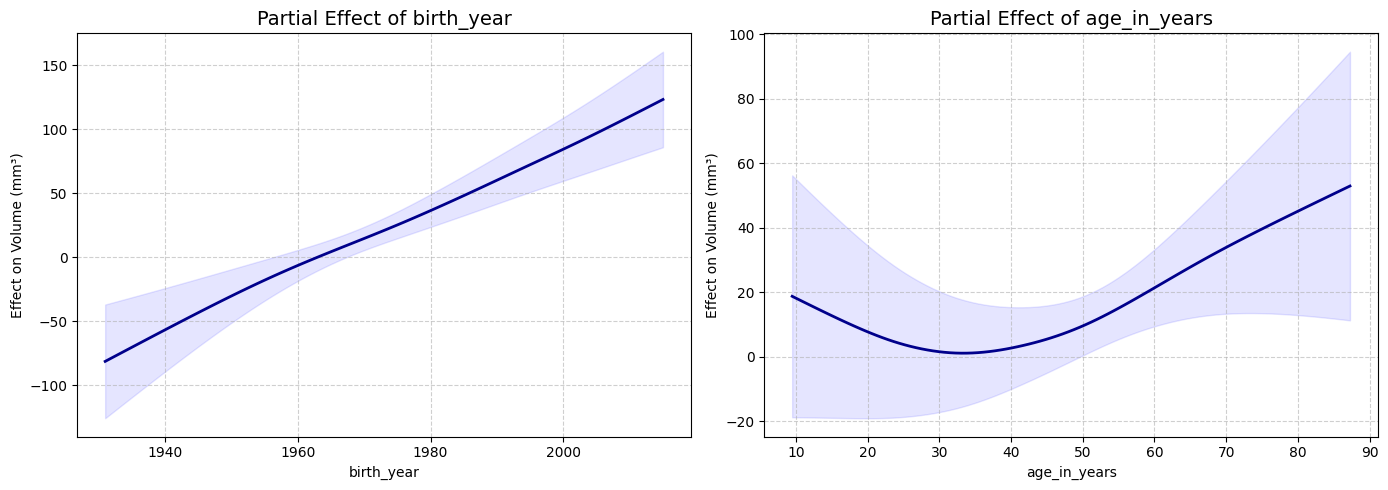

In [12]:
# --- Visualization ---
# We focus on the first two terms: Birth Year and Age
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axs):
    # generate_X_grid creates a range of values for the term 'i' 
    # while keeping other variables at their mean/mode
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=.95)
    
    ax.plot(XX[:, i], pdep, color='darkblue', lw=2)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='blue', alpha=0.1)
    
    # Use our feature_names list to set correct titles
    ax.set_title(f'Partial Effect of {feature_names[i]}', fontsize=14)
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel('Effect on Volume (mm³)')
    ax.grid(True, ls='--', alpha=0.6)

plt.tight_layout()
plt.show()

# GAMM

Run the R script GAMM.R
Then load the results - 
* all_effects: the components of the GAMM, estimations, std., statistic, p value
fixed effect (linear) - includes birth_year, sex, intercept
                        estimate is beta coef
                        statistic is t value
smooth effect (non-linear) - includes age_in_years, tiv
                        estimate is EDF (Estimated Degrees of Freedom). It describes the complexity of the curve. 1=linear, >1=non-linear, >5 highly complex
                        statistic is F value

* all_roi_curves : fit and se per roi 

In [13]:
# birth year is smoothed
all_effects = pd.read_csv("/home/gaia/all_effects.csv")
all_roi_curves = pd.read_csv("/home/gaia/all_roi_curves.csv")

all_roi_curves.rename(columns={'s(age_in_years)': 'age', 's(birth_year)': 'birth_year'}, inplace=True)

### sanity test for the differences in parameters between rois

In [14]:

# group all_roi_curves by roi 
roi1 = all_roi_curves[all_roi_curves['roi'] == 421]
roi2 = all_roi_curves[all_roi_curves['roi'] == 280]

# remove the index and roi columns in each 
roi1 = roi1.drop(columns=['roi'])
roi2 = roi2.drop(columns=['roi'])

# reset the index
roi1 = roi1.reset_index(drop=True)
roi2 = roi2.reset_index(drop=True)

# is roi1 == roi2? 
print(roi1.equals(roi2))

False


### Multiple comparison correction

In [15]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

# 1. Load your results
df_results = all_effects

# 2. Filter for a specific term you want to test (e.g., the Age smooth)
mask = (df_results['term'] == 's(birth_year)')
age_pvals = df_results.loc[mask, 'PValue']

# 3. Apply FDR (Benjamini-Hochberg)
significant, p_corrected, _, _ = multipletests(age_pvals, alpha=0.05, method='fdr_bh')

# 4. Add the results back to your dataframe
df_results.loc[mask, 'PValue_FDR'] = p_corrected
df_results.loc[mask, 'is_significant_FDR'] = significant

# Count how many ROIs survived
print(f"Significant ROIs after FDR: {significant.sum()}")

significant_rois = df_results.loc[mask & df_results['is_significant_FDR'], 'roi']

# 5. Extract the estimates for the significant ROIs

filtered_df = df_results[
    (df_results['roi'].isin(significant_rois)) & 
    (df_results['term'].isin(['s(birth_year)', 's(age_in_years)']))
]

# 2. Pivot the data so 'roi' is the index and 'term' values become columns
estimates_of_significant_rois = filtered_df.pivot(
    index='roi', 
    columns='term', 
    values='Estimate'
).reset_index()

estimates_of_significant_rois.rename(columns={'s(age_in_years)': 'age', 's(birth_year)': 'birth_year'}, inplace=True)


Significant ROIs after FDR: 410


In [16]:
print(df_results.columns)
print(df_results['term'].unique())

Index(['term', 'effect_type', 'Estimate', 'StdError', 'Statistic', 'PValue',
       'roi', 'PValue_FDR', 'is_significant_FDR'],
      dtype='object')
['(Intercept)' 'tiv' 'sexM' 's(age_in_years)' 's(birth_year)']


### Visualization

Mapping 410 ROI estimates to atlas...


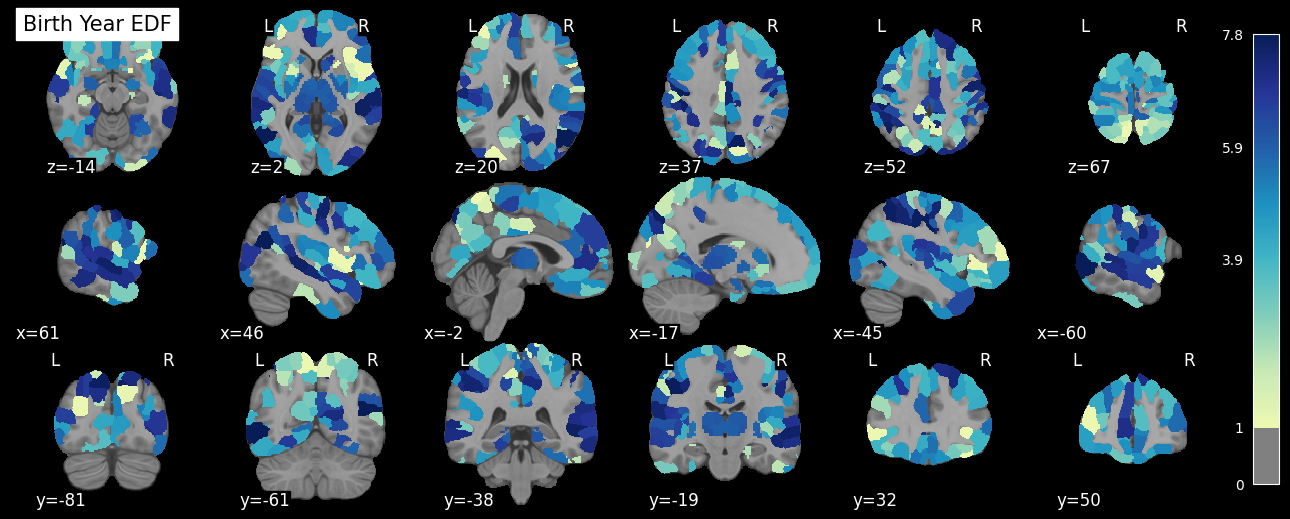

In [17]:
# for significant rois (is_significant_FDR == True), plot on the brain. color code by estimate (1=linear, 1-5=non-linear)

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template

# --- 1. Load Your Atlas ---
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

# --- 2. Map Estimates from result_df ---
# We create a dictionary mapping the ROI label to the Birth Year estimate
# We assume 'roi' contains the numeric label that matches the atlas voxels
birth_year_map = dict(zip(estimates_of_significant_rois['roi'], estimates_of_significant_rois['birth_year']))

# --- 3. Create the statistical map ---
# Initialize with zeros
stat_map_data = np.zeros_like(atlas_labels, dtype=float)

print(f"Mapping {len(birth_year_map)} ROI estimates to atlas...")

for label, estimate in birth_year_map.items():
    # Only map if the estimate is not NaN
    if pd.notnull(estimate):
        # Important: Ensure label is cast to int if it's stored as a string or float
        stat_map_data[atlas_labels == int(label)] = estimate

# Create the NIfTI image
birth_year_map_img = new_img_like(atlas_img, stat_map_data)

# --- 4. Plotting ---
bg_img = load_mni152_template()

# Note: I removed threshold=1 because estimates (coefficients) are often 
# smaller than T-statistics. If your plot is empty, lower the threshold.
plotting.plot_stat_map(
    stat_map_img=birth_year_map_img,
    bg_img=bg_img,
    title="Birth Year EDF",
    cmap='YlGnBu',
    symmetric_cbar=False,
    threshold=1, # Set very low to see all significant effects
    display_mode='mosaic',
    cut_coords=(6, 6, 6),
    colorbar=True
)

plotting.show()

In [18]:
# plot the data with prediction
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_roi_trajectory(roi_name, variable):
    data = all_roi_curves[all_roi_curves['roi'] == roi_name]
    
    plt.figure(figsize=(10, 6))
    
    # Plot the main curve
    sns.lineplot(data=data, x=variable, y='fit', color='blue', label='Predicted Volume')
    
    # Add Confidence Intervals (Fit +/- 1.96 * SE)
    plt.fill_between(data[variable], 
                     data['fit'] - 1.96 * data['se'], 
                     data['fit'] + 1.96 * data['se'], 
                     alpha=0.2, color='blue', label='95% CI')
    
    # add the mean volume as a dotted line 
    mean_volume = data['fit'].mean()
    plt.axhline(mean_volume, color='blue', linestyle='dotted', label='Mean Volume')

    plt.title(f'Aging Trajectory for {roi_name}')
    plt.xlabel(variable)
    plt.ylabel('Volume (mm³)')
    plt.legend()
    plt.show()

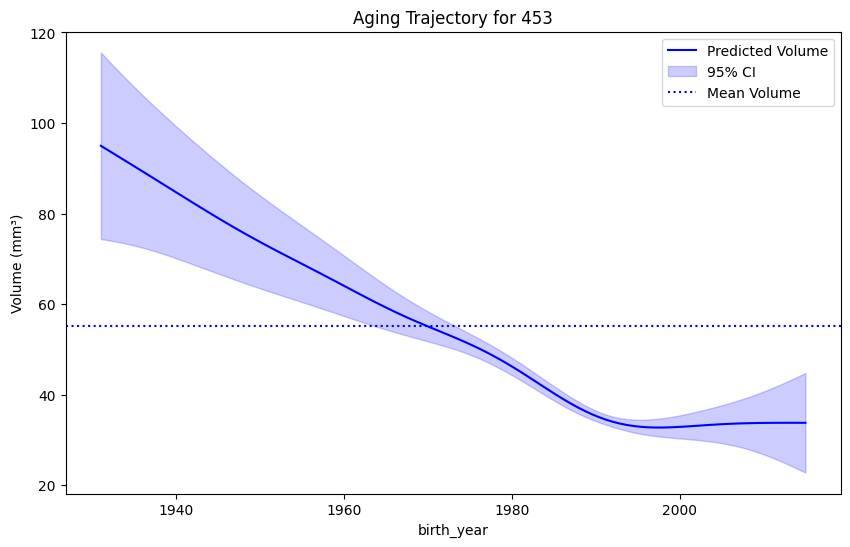

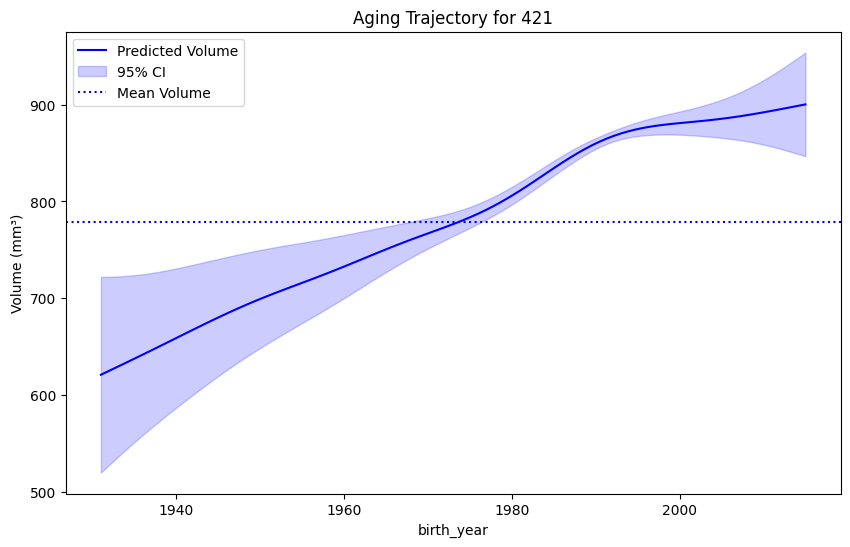

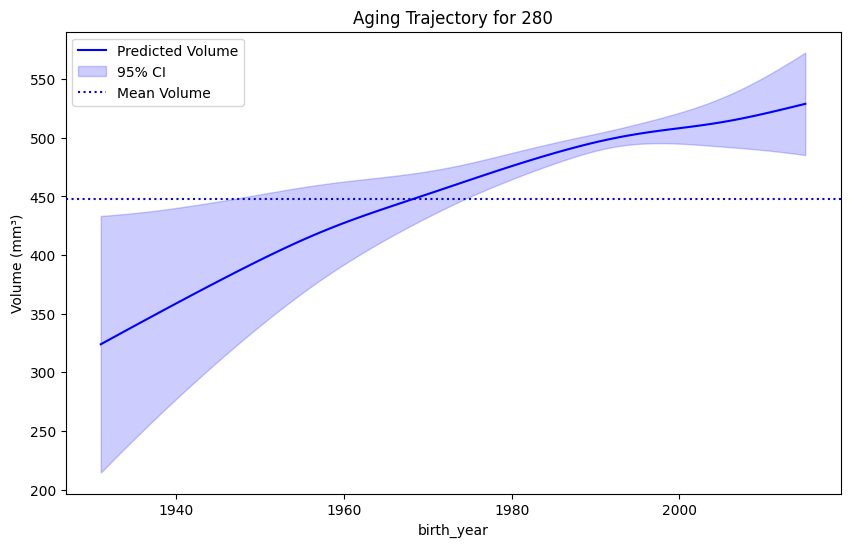

In [19]:
# for roi in estimates_of_significant_rois['roi']:
#     plot_roi_trajectory(roi, 'birth_year')

plot_roi_trajectory(453, 'birth_year')
plot_roi_trajectory(421, 'birth_year')
plot_roi_trajectory(280, 'birth_year')

### Hierarchical Clustering of ROIs

Text(144.44444444444446, 0.5, 'Brain Regions (454)')

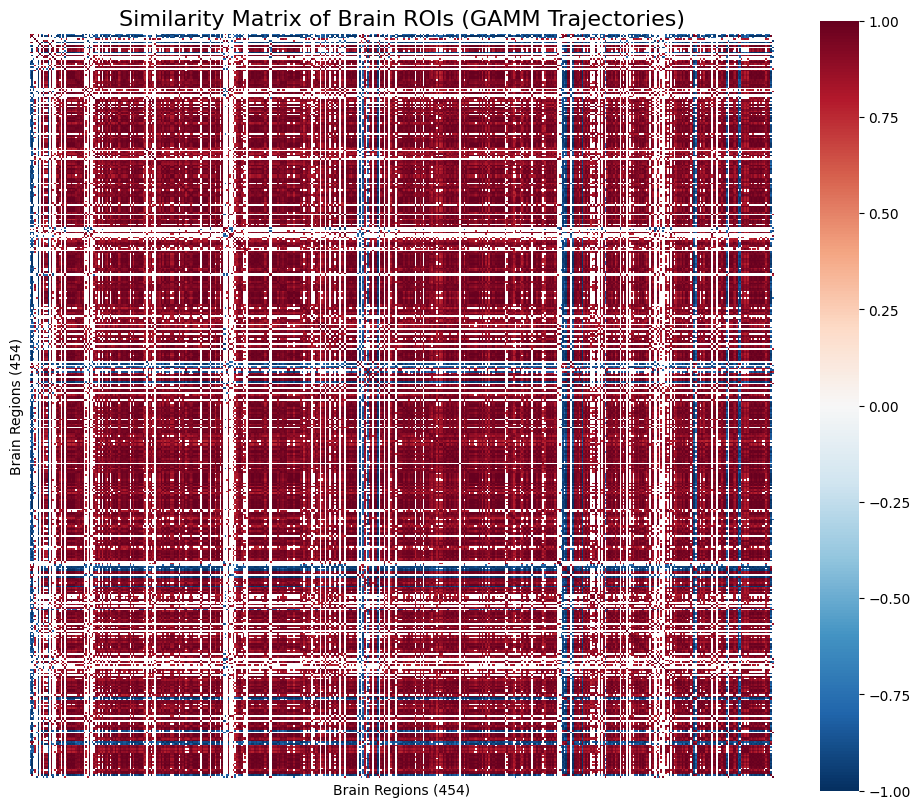

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

# Pivot the data: Rows = ROIs, Columns = Birth Year points
# This creates a "matrix of shapes"
pivot_df = all_roi_curves.pivot(index='roi', columns='birth_year', values='fit')


# Z-score normalization
# IMPORTANT: This ensures you cluster by SHAPE (trajectory) rather than absolute volume (size).
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df.T).T 
# We transpose because StandardScaler scales columns, but we want to scale each ROI curve

corr_matrix = pivot_df.T.corr()

threshold = 0.75
mask = np.abs(corr_matrix) < threshold

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            mask=mask,           # This hides values below the threshold
            cmap='RdBu_r',       
            center=0,            
            xticklabels=False,   
            yticklabels=False, 
            square=True)


plt.title('Similarity Matrix of Brain ROIs (GAMM Trajectories)', fontsize=16)
plt.xlabel('Brain Regions (454)')
plt.ylabel('Brain Regions (454)')


In [21]:
# list the couples of similarity >0.75 or <-0.75
high_similarity_pairs = []
threshold = 0.9
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            high_similarity_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

print(f"amount of high similarity pairs: {len(high_similarity_pairs)}")
print(f"{len(high_similarity_pairs)} out of {len(corr_matrix.columns) * (len(corr_matrix.columns) - 1) / 2} total pairs are more than {threshold} correlation")
print(f"precentage: {len(high_similarity_pairs) / (len(corr_matrix.columns) * (len(corr_matrix.columns) - 1) / 2) * 100:.2f}%")

amount of high similarity pairs: 46488
46488 out of 102831.0 total pairs are more than 0.9 correlation
precentage: 45.21%


### clustering
maybe cluster in other ways, I don't know how many clusters and how it's clustered

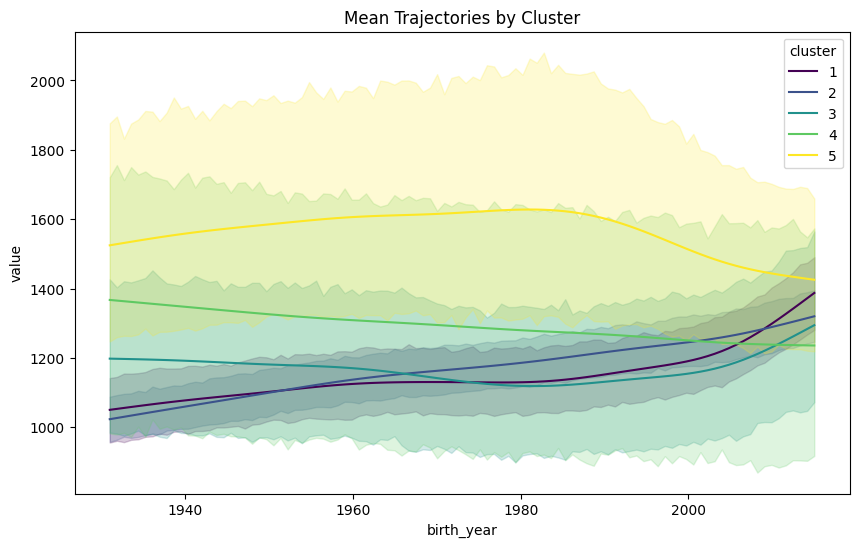

Cluster 1: 152 ROIs: [4, 19, 21, 23, 30, 31, 33, 35, 39, 41, 42, 43, 45, 47, 48, 50, 55, 56, 61, 62, 64, 66, 71, 74, 76, 79, 80, 82, 87, 88, 92, 94, 99, 110, 114, 115, 117, 118, 125, 127, 128, 129, 131, 132, 133, 134, 144, 145, 152, 155, 166, 168, 169, 171, 174, 177, 179, 180, 182, 185, 187, 189, 191, 192, 205, 210, 221, 224, 225, 229, 232, 236, 239, 241, 245, 247, 248, 249, 251, 252, 254, 257, 259, 260, 262, 263, 264, 266, 277, 279, 281, 292, 296, 301, 304, 307, 310, 313, 314, 315, 317, 319, 321, 335, 339, 341, 343, 344, 345, 347, 349, 351, 356, 358, 359, 362, 363, 367, 368, 369, 370, 371, 372, 377, 378, 386, 389, 390, 394, 395, 396, 397, 398, 400, 403, 404, 408, 409, 410, 411, 412, 415, 418, 423, 430, 431, 435, 436, 437, 438, 439, 450]
Cluster 2: 233 ROIs: [5, 8, 9, 10, 11, 14, 15, 17, 18, 24, 25, 26, 27, 28, 29, 32, 37, 40, 44, 46, 49, 51, 52, 53, 54, 57, 58, 59, 60, 63, 65, 67, 68, 69, 70, 73, 75, 78, 81, 83, 84, 85, 86, 89, 90, 91, 93, 95, 96, 97, 98, 100, 101, 102, 103, 104, 106,

In [22]:
Z = linkage(scaled_data, method='ward')
# 6. Extract Cluster Labels
k = 5
pivot_df['cluster'] = fcluster(Z, k, criterion='maxclust')

# 7. Visualize the "Average Trajectory" per Cluster
cluster_data = pivot_df.reset_index().melt(id_vars=['roi', 'cluster'], value_vars=pivot_df.columns[:-1], var_name='birth_year', value_name='value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=cluster_data, x='birth_year', y='value', hue='cluster', palette='viridis')
plt.title("Mean Trajectories by Cluster")
plt.show()

# print the areas per cluster
for cluster_id in range(1, k+1):
    cluster_rois = pivot_df[pivot_df['cluster'] == cluster_id].index.tolist()
    print(f"Cluster {cluster_id}: {len(cluster_rois)} ROIs: {cluster_rois}")




In [23]:
# remove duplicates in  cluster_data 
# drop the columns birth_year and value from cluster_data
# cluster_data = cluster_data.drop(columns=['birth_year', 'value'])
cluster_data = cluster_data.drop_duplicates(subset=['roi', 'cluster'])

cluster_data['roi'] = pd.to_numeric(cluster_data['roi'])
atlas_csv['index'] = pd.to_numeric(atlas_csv['index'])

# add to cluter_data information from atlas_csv
cluster_data = cluster_data.merge(
    atlas_csv[['index', 'component', 'network', 'base_name']], 
    left_on='roi', 
    right_on='index', 
    how='left'
)

cluster_data = cluster_data.drop(columns=['index'])

In [24]:
def analyze_clusters(cluster_data, k):
    """loads clustering df of rois, adds the info from the atlas and visualizations

    Parameters
    ----------
    cluster_data : DataFrame
        2 columns: roi and cluster. roi is a value between 1-454
        cluster is numeric from 1-k
    k : numeric
        number of clusters
    """
    
    atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")

    cluster_data = cluster_data.drop_duplicates(subset=['roi', 'cluster'])

    cluster_data['roi'] = pd.to_numeric(cluster_data['roi'])
    atlas_csv['index'] = pd.to_numeric(atlas_csv['index'])

    # add to cluter_data information from atlas_csv
    cluster_data = cluster_data.merge(
        atlas_csv[['index', 'component', 'network', 'base_name']], 
        left_on='roi', 
        right_on='index', 
        how='left'
    )
    cluster_data = cluster_data.drop(columns=['index'])

    # for each cluster, pie chart by component 
    print("analysis by component")
    for cluster_id in range(1, k+1):
        cluster_subset = cluster_data[cluster_data['cluster'] == cluster_id]
        component_counts = cluster_subset['component'].value_counts()
        plt.figure(figsize=(6, 6))
        plt.pie(component_counts.values, labels=component_counts.index, autopct='%1.1f%%')
        plt.title(f"Component Distribution for Cluster {cluster_id}")
        plt.show()

    # for each cluster, pie chart by network 
    print("analysis by network")
    for cluster_id in range(1, k+1):
        cluster_subset = cluster_data[cluster_data['cluster'] == cluster_id]
        network_counts = cluster_subset['network'].value_counts()
        plt.figure(figsize=(6, 6))
        plt.pie(network_counts.values, labels=network_counts.index, autopct='%1.1f%%')
        plt.title(f"Network Distribution for Cluster {cluster_id}")
        plt.show()

/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


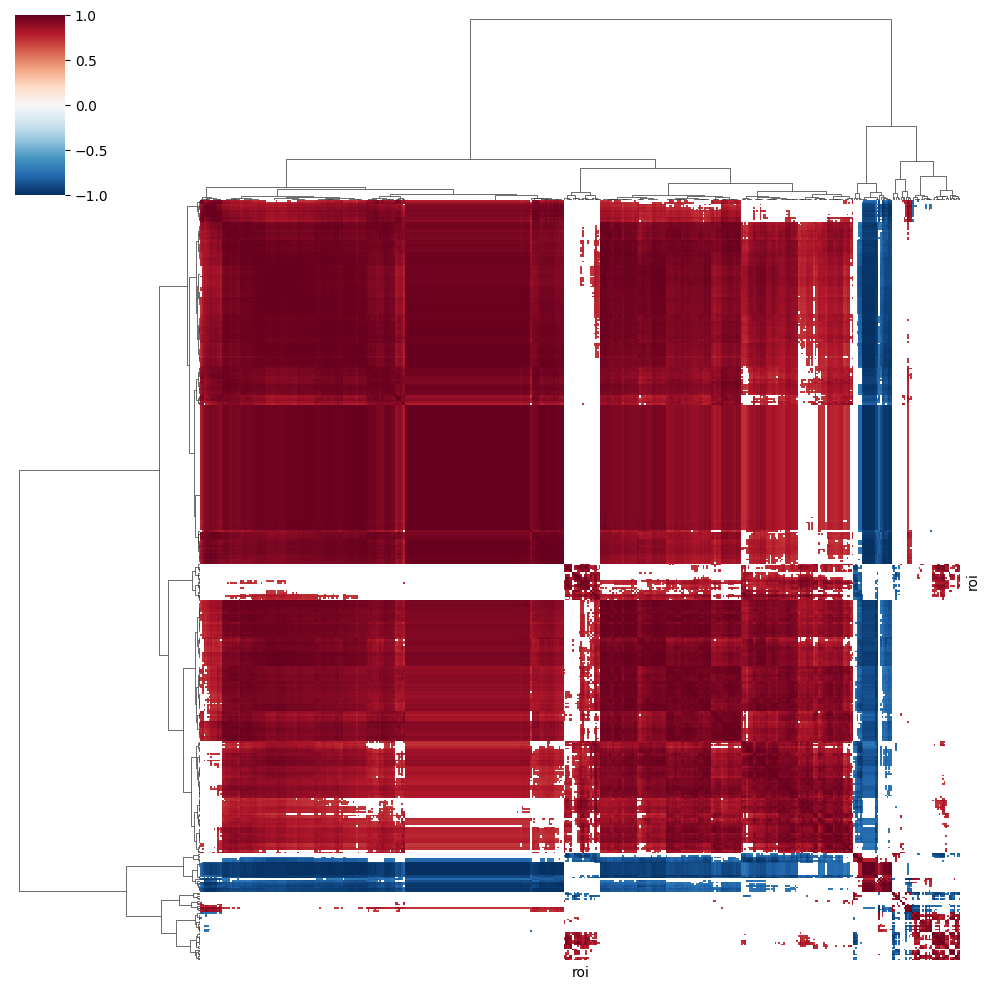

In [25]:
# present over threshold 
threshold = 0.7
mask = np.abs(corr_matrix) < threshold

# Use Clustermap for a more organized view
g = sns.clustermap(corr_matrix,
                mask = mask,
               cmap='RdBu_r', 
               center=0, 
               xticklabels=False, 
               yticklabels=False,
               method='ward') # This uses the Ward method you want for clustering



In [26]:
# Assuming 'g' is your clustermap object: g = sns.clustermap(...)
reordered_roi_names = corr_matrix.columns[g.dendrogram_row.reordered_ind]

# This list now matches the order of the heatmap from top-to-bottom/left-to-right
print(reordered_roi_names)

from scipy.cluster.hierarchy import fcluster

# 1. 'Cut' the tree to get a specific number of groups
# Based on your image, 3 or 4 clusters should capture those big blocks
cluster_labels = fcluster(g.dendrogram_row.linkage, t=4, criterion='maxclust')

# 2. Create a DataFrame mapping ROIs to their Cluster ID
roi_mapping = pd.DataFrame({
    'ROI_Name': corr_matrix.columns,
    'Cluster_ID': cluster_labels
})

# 3. Sort them to match the Heatmap order
sorted_mapping = roi_mapping.iloc[g.dendrogram_row.reordered_ind]

# rename columns for clarity
sorted_mapping = sorted_mapping.rename(columns={'ROI_Name': 'roi', 'Cluster_ID': 'cluster'})

Index([126, 208,  40,  11,  10, 297, 158, 384,  96, 162,
       ...
       217,  77, 323,  72, 427, 124, 382,  13, 181, 361],
      dtype='int64', name='roi', length=454)


analysis by component


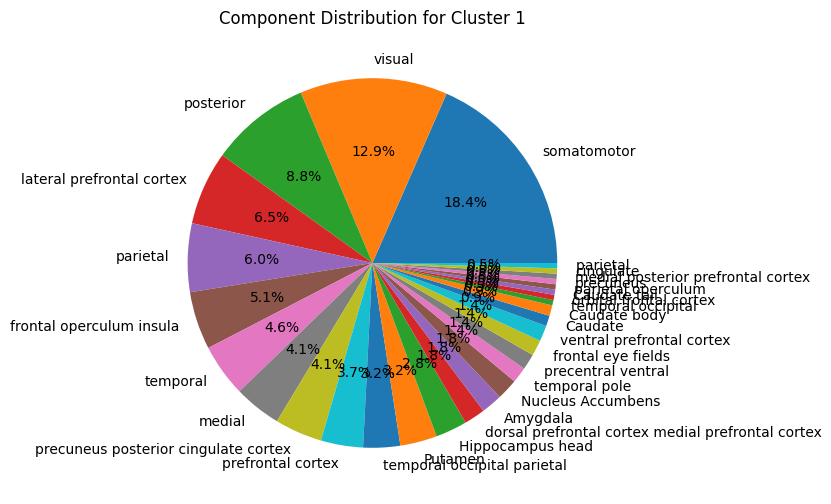

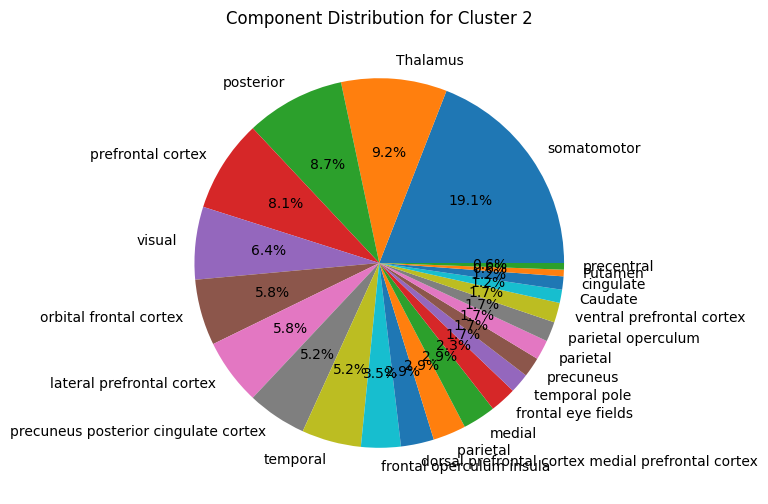

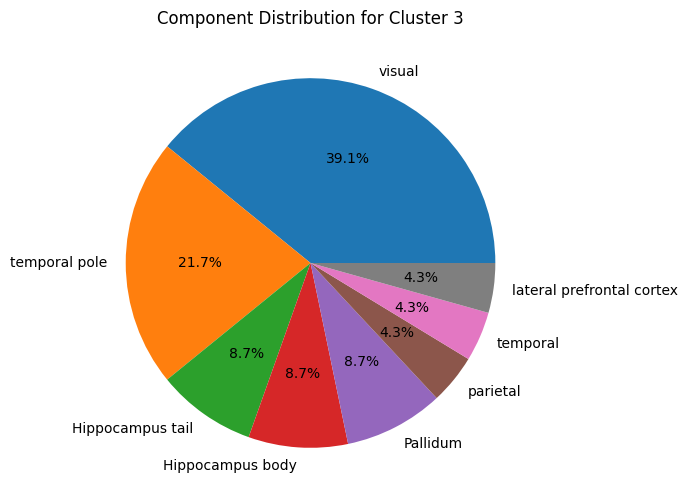

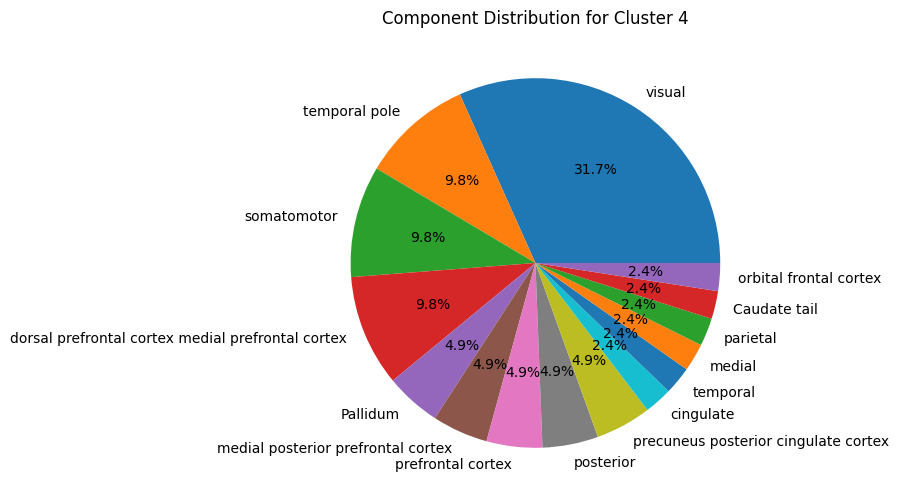

analysis by network


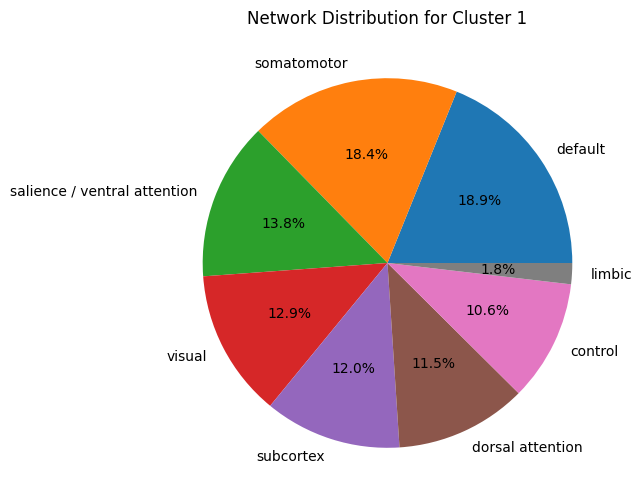

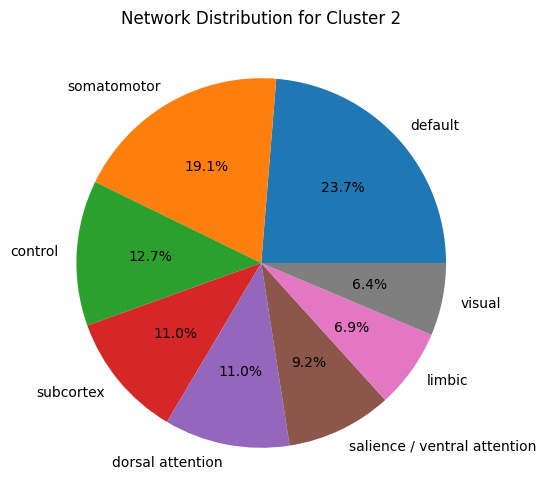

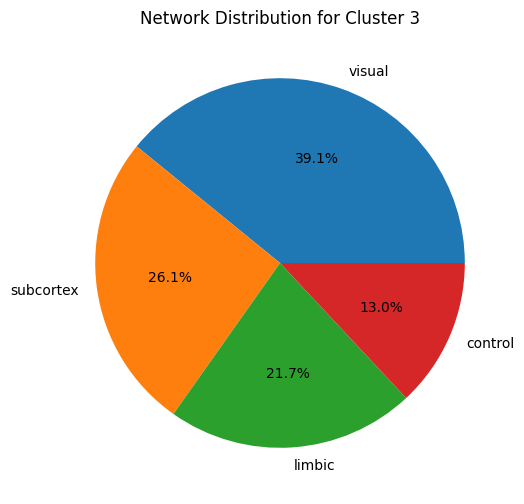

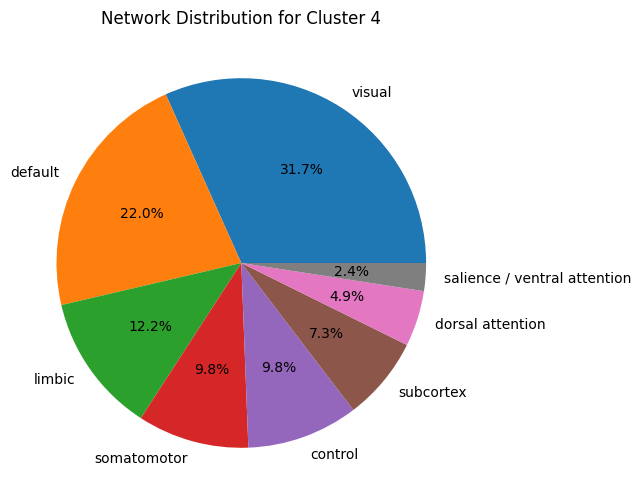

In [27]:
analyze_clusters(sorted_mapping, 4)

### QA - Residualizing